In [1]:
import sys
import os
import h5py
from pathlib import Path
from datetime import datetime

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from helpers.config import *
from model_training.model import *

import torch
from torch.utils.data import Dataset, random_split, DataLoader
import torchvision.models as models
import torch.nn as nn
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [2]:
model = CNN(width=6, bn=True, normalise=False)
device = torch.device("mps")
weights_path = TRAINING_RESULTS/'ext_high_mass'/'run_290326_154951'/'best_model_weights.pth'
#weights_path = TRAINING_RESULTS/'ext_high_mass'/ 'good_runs' /'run_090326_150123'/'best_model_weights.pth'

model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
model.eval()


CNN(
  (conv1): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(6, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.0, inplace=False)
  (fc1): Linear(in_features=12288, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=2, bias=True)
)

## Plotter

In [37]:
results_path = TRAINING_RESULTS/'low_mass'/ 'good_runs' /'run_090326_165434'/'results.pt'
results = torch.load(results_path)
iters, train_loss, train_soft_acc, val_soft_acc,\
          train_hard_acc, val_hard_acc, test_soft_acc, test_hard_acc= results

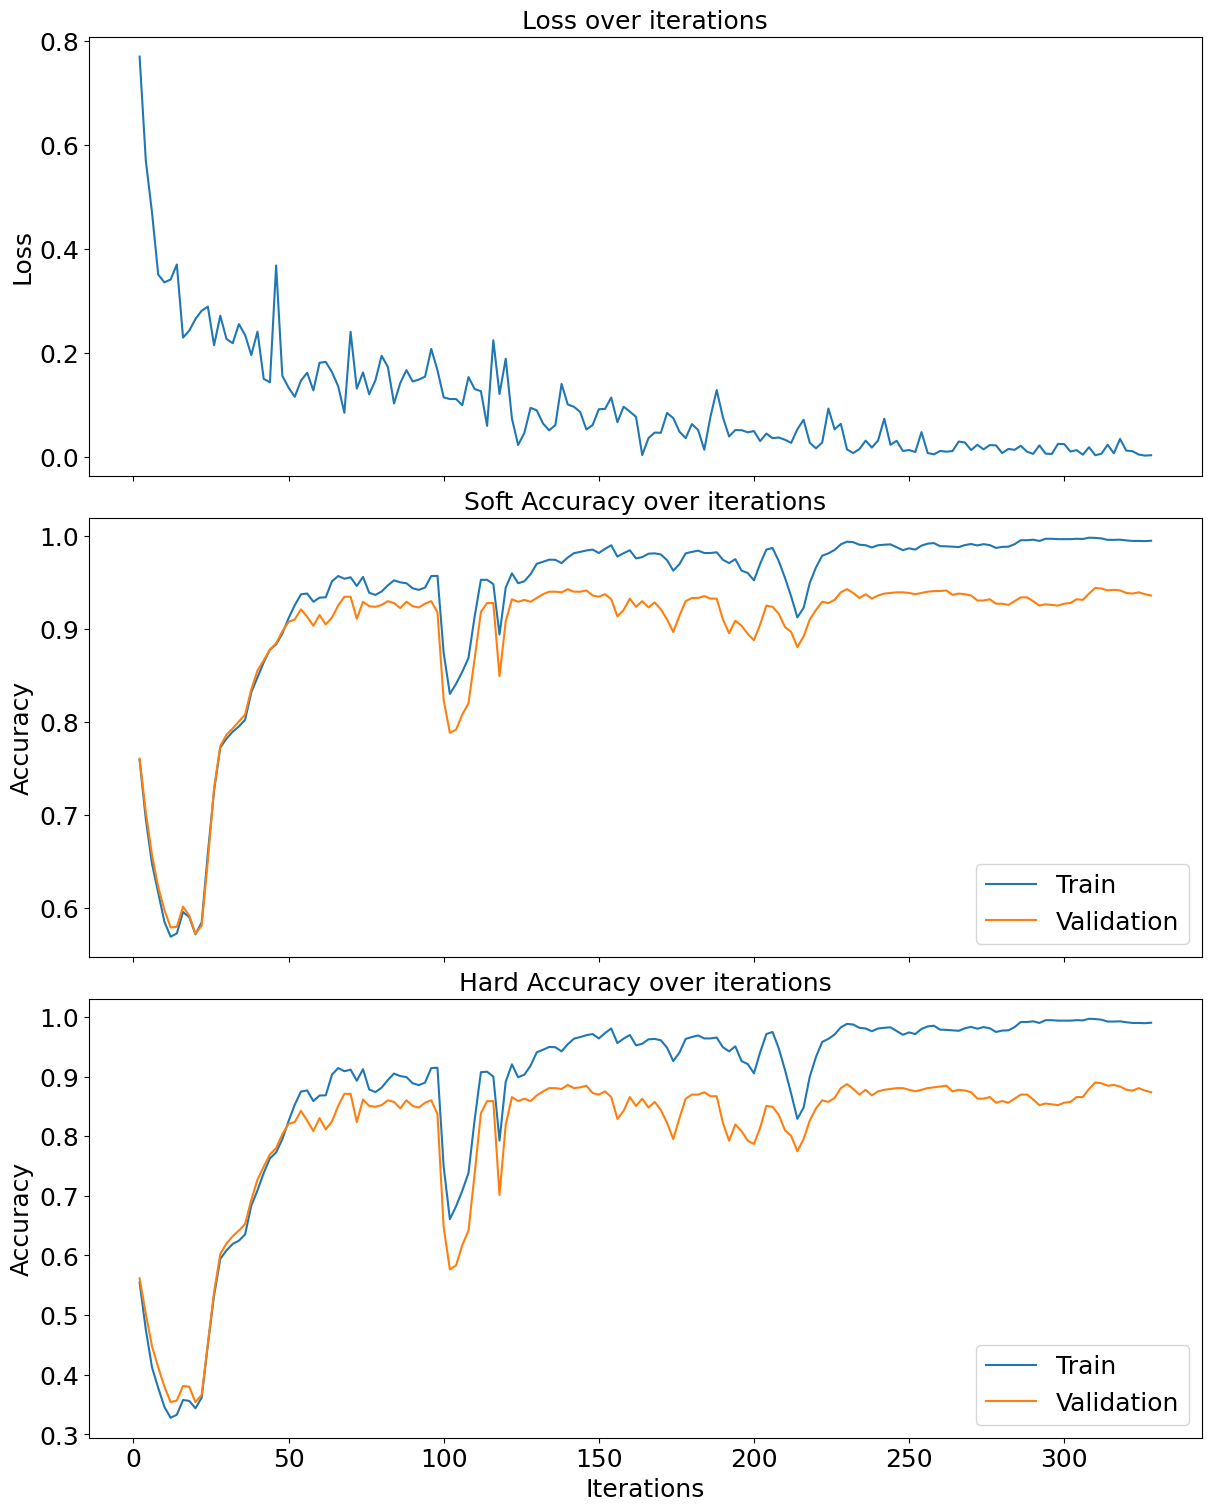

In [38]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(12, 15), constrained_layout=True)

axes[0].plot(iters[:len(train_loss)], train_loss)
axes[0].set_title("Loss over iterations",  fontsize=18)
axes[0].set_ylabel("Loss",  fontsize=18)
axes[0].tick_params(axis='y', labelsize=18)

axes[1].plot(iters[:len(train_soft_acc)], train_soft_acc)
axes[1].plot(iters[:len(val_soft_acc)], val_soft_acc)
axes[1].set_title("Soft Accuracy over iterations", fontsize=18)
axes[1].set_ylabel("Accuracy",  fontsize=18)
axes[1].legend(["Train", "Validation"],  fontsize=18)
axes[1].tick_params(axis='y', labelsize=18)

axes[2].plot(iters[:len(train_hard_acc)], train_hard_acc)
axes[2].plot(iters[:len(val_hard_acc)], val_hard_acc)
axes[2].set_title("Hard Accuracy over iterations",  fontsize=18)
axes[2].set_xlabel("Iterations",  fontsize=18)
axes[2].set_ylabel("Accuracy",  fontsize=18)
axes[2].legend(["Train", "Validation"],  fontsize=18)

axes[2].tick_params(axis='x', labelsize=18)
axes[2].tick_params(axis='y', labelsize=18)
plt.show()

## Confusion matrix

In [3]:
dataset = LISADataset(training_ehm_dataset_path)

N = len(dataset)
train_size = int(0.7 * N)
val_size   = int(0.2 * N)
test_size  = N - train_size - val_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size], generator=generator)

In [4]:
model.eval()

loader = DataLoader(test_dataset, batch_size=64)

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in loader:
        images = batch[0].to(device)
        labels = batch[1]

        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_preds.append(preds.cpu())
        all_labels.append(labels)

preds = torch.cat(all_preds)
labels = torch.cat(all_labels)

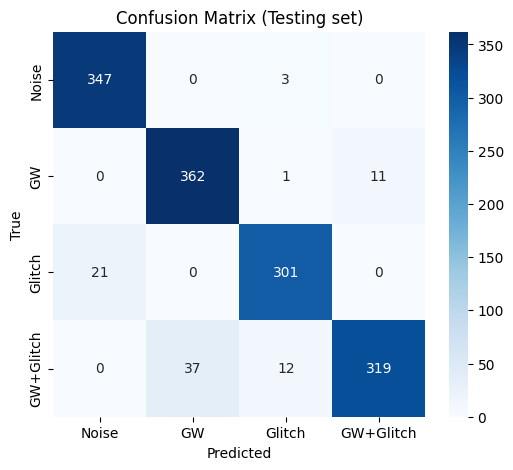

In [5]:
def label_to_class(y):
    return y[:,0]*1 + y[:,1]*2

true_class = label_to_class(labels)
pred_class = label_to_class(preds)
cm = confusion_matrix(true_class, pred_class)

labels_names = ["Noise", "GW", "Glitch", "GW+Glitch"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_names,
            yticklabels=labels_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Testing set)")

plt.show()

In [67]:
np.where((true_class == 3)&(pred_class == 3))[0][0:20]

array([ 0,  2, 10, 19, 21, 22, 25, 27, 33, 34, 37, 40, 42, 46,
       48, 50, 53, 57, 76, 78])

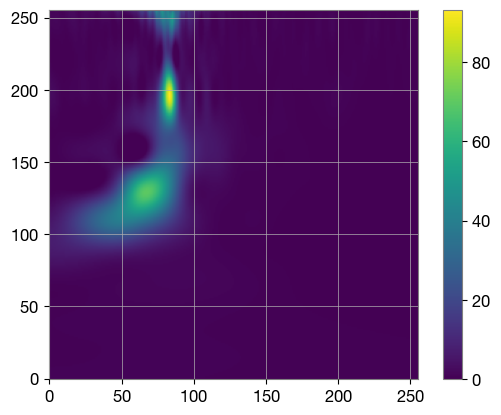

True label: tensor([1., 1.])
Sim index: 398
Time index: 0


: 

In [ ]:
image, label, sim_index, time_index = test_dataset[76]
plt.imshow(image[0], origin='lower')
plt.colorbar()
plt.show()
print('True label:', label)
print('Sim index:', sim_index)
print('Time index:', time_index)

## Time centering

In [18]:
from helpers.qtransform import *
from helpers.simulation import *

MASS_CATEGORY = 'ext_high_mass'  # 'low_mass', 'high_mass', 'ext_high_mass'
SPEC = SPECS[MASS_CATEGORY]

RESOLUTION = 256
REPRESENTATION = 'qscan'  # 'qscan' or 'varqscan'

def run_one_sample(args):
    tcen, X, Y, Z = args
    tdi_dict = make_tdi_dict(X, Y, Z)
    
    event = {'t_inj': PIPE['t_inj'] - tcen}

    QT = np.zeros((RESOLUTION, RESOLUTION, 3))
    for channel in ['A', 'E', 'T']:
        if REPRESENTATION == 'varqscan':
            t_arr, f_arr, data = varq_transform(tdi_dict, channel, PIPE, event, resolution=RESOLUTION,
                                        frange=SPEC['frange'], trange=SPEC['trange'], Qvals=SPEC['Qvals'])
        elif REPRESENTATION == 'qscan':
            t_arr, f_arr, data = generate_qscan(tdi_dict, channel, PIPE, event, resolution=RESOLUTION,
                             frange=SPEC['frange'], trange=SPEC['trange'], Q=SPEC['Q'])

        QT[:, :, ['A', 'E', 'T'].index(channel)] = data

    return QT, t_arr, f_arr

In [55]:
gws = [{'type': 'BinaryInspiralGW', 'm1': 2e6, 'm2': 3e6, 'd': 1e4,
        'spin1': 0, 'spin2': 0, 't_inj': PIPE['t_inj'], 'domain': 'freq',
        'gw_beta':0, 'gw_lambda':0}]
glitches = [{'type':'IntegratedShapeletGlitch', 't_inj': PIPE['t_inj'], 'beta':4.32e1,
             'level':2*4.91e-13*4.32e1, 'inj_point':'tm_13'}]

run_simulation(
            gws, glitches, PIPE,
            gw_path, None, orbits_path,
            simulation_path,
            disable_noise=PIPE['keep_noises'],
            seed=42
        )
raw_dict = run_tdi(simulation_path, PIPE)

You are using an orbit file in a version that might not be fully supported
Cannot read sampling parameters from '/Users/aryamannrao/Documents/MSc/LISAGlitchSignalClassifier/dist/default_gw_output.h5'
You are using an orbit file in a version that might not be fully supported
Using default set of locking beatnote frequencies might cause interferometric beatnote frequencies to fall outside the requirement range of 5..25 MHz
You are using a measurement file in a version that might not be fully supported (got '2.1.0', official support up to '2.0')


In [56]:
tcen_arr = np.linspace(-3, 3, 50)*3600

image_arr = np.zeros((len(tcen_arr), 256, 256, 3))
for i, tcen in enumerate(tcen_arr):
    args = (tcen, raw_dict['X'], raw_dict['Y'], raw_dict['Z'])
    QT, tarr, farr = run_one_sample(args)
    image_arr[i, :, :, :] = QT

image_arr = torch.tensor(image_arr, dtype=torch.float32)
image_arr = image_arr.permute(0, 3, 1, 2)

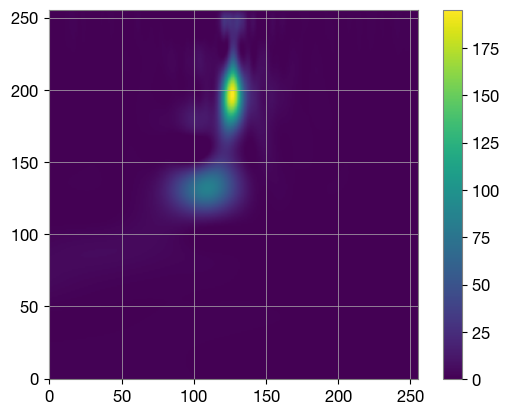

In [64]:
plt.imshow(image_arr[25][0], origin='lower')
plt.colorbar()
plt.show()

In [58]:
with torch.no_grad():
    outputs = model(image_arr.to(device).contiguous())
    probs = torch.sigmoid(outputs)

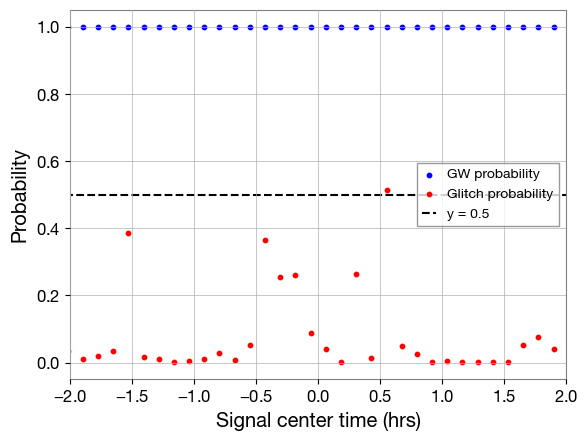

In [60]:
gw_prob = probs[:, 0].detach().cpu().numpy()
glitch_prob = probs[:, 1].detach().cpu().numpy()
tcen_act = 1.87*3600
plt.scatter(tcen_arr/3600, gw_prob, color='blue', label='GW probability', s=10)
plt.scatter(tcen_arr/3600, glitch_prob, color='red', label='Glitch probability', s=10)
plt.hlines(y=[0.5], xmin=-3, xmax=3, color='black', linestyle='dashed', label='y = 0.5')
plt.xlabel('Signal center time (hrs)')
plt.ylabel('Probability')
plt.legend(fontsize=10)
plt.xlim(-2,2)
#plt.ylim(-0.5, 1.2)
plt.show()

In [54]:
chirp_mass(2e6, 2e6)/1e6

1.741101126592247